In [1]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
# read in all the words
words = open('names.txt', 'r').read().splitlines()
words[:8]

['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']

In [3]:
def getStoi(ch:str):
    if ch == '.':
        return 0
    else:
        return ord(ch) - ord('a') + 1

def getItos(n:int):
    if n == 0:
        return '.'
    else :
        return chr(n + ord('a')-1)

In [7]:
block_size = 3 #context length: how many characters do we take to predict the next one?
# build the dataset
def build_dataset(words, block_size=3):
    # Create the training set of bigrams
    X, Y = [], []
    for w in words:
        #print(w)
        context = [0] * block_size 
        for ch in w + '.':
            ix = getStoi(ch)
            X.append(context)
            Y.append(ix)
            #print(''.join(getItos(i) for i in context), '--->', getItos(ix))
            context = context[1:] + [ix] #crop and append
    X = torch.tensor(X)
    Y = torch.tensor(Y)
    return X, Y

vocab_size = 27

import random
random.seed(42)
random.shuffle(words)
n1 = int(0.8*len(words))
n2 = int(0.9*len(words))

Xtr, Ytr = build_dataset(words[:n1])     #80
Xdev, Ydev = build_dataset(words[n1:n2]) #10
Xte, Yte = build_dataset(words[n2:])     #10

In [8]:
Xtr.shape, Xtr.dtype, Ytr.shape, Ytr.dtype

(torch.Size([182437, 3]), torch.int64, torch.Size([182437]), torch.int64)

In [66]:
n_embd = 10 # the dimensionality of the character embedding vectors
n_hidden = 200 # the number of neurons in the hidden layer of the MLP

g = torch.Generator().manual_seed(2147483647)
C = torch.randn((vocab_size, n_embd), generator=g)
W1 = torch.randn((n_embd * block_size, n_hidden), generator=g) * (5/3)/ ((n_embd * block_size)**0.5)
b1 = torch.randn(n_hidden, generator=g) * 0.02
W2 = torch.randn([n_hidden, vocab_size], generator=g) * 0.01
b2 = torch.randn(vocab_size, generator=g) * 0

bngain = torch.ones((1, n_hidden))
bnbias = torch.zeros((1,n_hidden))
bnmean_running = torch.zeros((1, n_hidden))
bnstd_running = torch.ones((1, n_hidden))

parameters = [C, W1, b1, W2, b2, bngain, bnbias]

In [67]:
sum(p.nelement() for p in parameters)

12297

In [68]:
for p in parameters:
    p.requires_grad = True

In [69]:
lre = torch.linspace(-3, 0, 1000)
lrs = 10**lre

In [70]:
max_steps = 200000
batch_size = 32
lossi = []
for i in range(max_steps):
    # minibatch construct
    ix = torch.randint(0, Xtr.shape[0], (batch_size,), generator=g)
    Xb, Yb = Xtr[ix], Ytr[ix] # batch X,Y
    
    # forward pass
    emb = C[Xb]
    hpreact = emb.view(-1, 30) @ W1 + b1
    bnmeani = hpreact.mean(0, keepdim=True)
    bnstdi = hpreact.std(0, keepdim=True)
    hpreact = bngain * (hpreact - bnmeani) /  bnstdi + bnbias

    with torch.no_grad():
        bnmean_running = 0.999 * bnmean_running + 0.001 * bnmeani
        bnstd_running = 0.999 * bnstd_running + 0.001 * bnstdi
        
    h = torch.tanh(hpreact)
    logits = h @ W2 + b2
    loss = F.cross_entropy(logits, Yb)
          
    # backward pass
    for p in parameters:
        p.grad = None
        
    loss.backward()
    
    # update
    lr = 0.1 if i < 100000 else 0.01 # step learnig rate decay
    for p in parameters:
        p.data += (-lr * p.grad)

    # track stats
    if i % 10000 == 0:
        print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')
    lossi.append(loss.log10().item())

print(loss.item())

      0/ 200000: 3.3054
  10000/ 200000: 1.7978
  20000/ 200000: 1.9030
  30000/ 200000: 2.4623
  40000/ 200000: 2.4436
  50000/ 200000: 1.8843
  60000/ 200000: 2.4164
  70000/ 200000: 2.1734
  80000/ 200000: 1.7217
  90000/ 200000: 2.3225
 100000/ 200000: 2.2514
 110000/ 200000: 2.1481
 120000/ 200000: 1.9692
 130000/ 200000: 1.7992
 140000/ 200000: 2.2786
 150000/ 200000: 2.1926
 160000/ 200000: 1.9286
 170000/ 200000: 2.1592
 180000/ 200000: 2.5601
 190000/ 200000: 1.7961
2.2288246154785156


(array([484., 243., 195., 150., 150., 109., 118., 102., 107., 117.,  90.,
        101., 109.,  95., 100., 100.,  96.,  95., 109.,  82.,  87., 117.,
        110., 111., 114.,  95., 100.,  85., 103.,  88., 107.,  86., 104.,
         87.,  94., 104.,  70.,  97., 101.,  91.,  96., 110., 107., 129.,
        112., 151., 165., 180., 235., 412.]),
 array([-9.99999583e-01, -9.59999810e-01, -9.20000038e-01, -8.80000266e-01,
        -8.40000494e-01, -8.00000721e-01, -7.60000949e-01, -7.20001177e-01,
        -6.80001404e-01, -6.40001632e-01, -6.00001860e-01, -5.60002087e-01,
        -5.20002315e-01, -4.80002543e-01, -4.40002770e-01, -4.00002998e-01,
        -3.60003226e-01, -3.20003453e-01, -2.80003681e-01, -2.40003909e-01,
        -2.00004137e-01, -1.60004364e-01, -1.20004592e-01, -8.00048196e-02,
        -4.00050473e-02, -5.27501106e-06,  3.99944973e-02,  7.99942696e-02,
         1.19994042e-01,  1.59993814e-01,  1.99993587e-01,  2.39993359e-01,
         2.79993131e-01,  3.19992903e-01,  3.59992

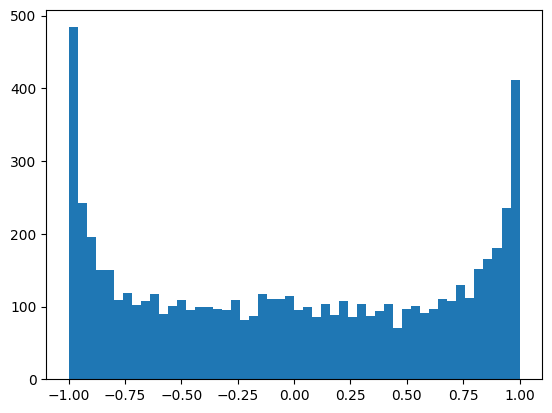

In [71]:
plt.hist(h.view(-1).tolist(), 50)

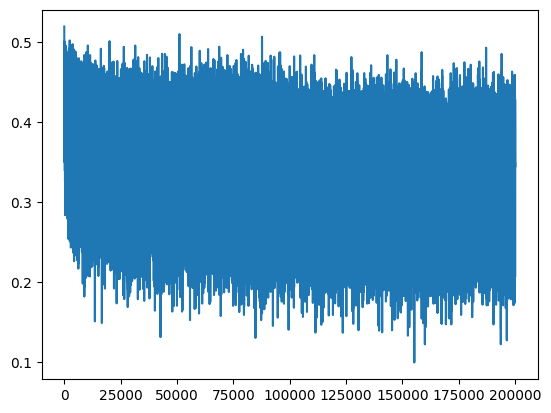

In [72]:
plt.plot(lossi)

In [73]:
# calibrate the batch norm at the end of training
with torch.no_grad():
    # pass the training set through
    emb = C[Xtr]
    hpreact = emb.view(emb.shape[0], -1) @ W1 + b1
    # measure the mean/std over the entire training set
    bnmean = hpreact.mean(0, keepdim=True)
    bnstd = hpreact.std(0, keepdim=True)

In [74]:
bnmean, bnmean_running, bnstd, bnstd_running

(tensor([[-2.2683e+00,  6.2918e-01, -1.7693e+00,  5.7350e-01,  7.2666e-01,
           1.2781e+00,  2.3042e+00, -1.2543e+00,  6.6148e-01,  1.9505e+00,
          -1.3849e+00, -2.3775e+00, -6.3545e-01, -7.4059e-01,  2.6320e-01,
          -4.9622e-01,  1.7032e-01, -2.2574e+00, -1.7901e-01,  1.5017e+00,
           3.1161e-01,  1.5464e-01, -4.6280e-01,  5.5117e-01,  4.5173e-01,
           1.8969e+00,  6.7926e-01,  2.4411e-01,  2.5550e-02,  1.8997e+00,
           2.6130e-01, -1.1650e+00, -3.4192e-01,  5.8094e-02,  8.2807e-02,
          -9.2194e-01,  7.2298e-01,  2.9732e-01, -1.1801e+00,  3.0584e-01,
           3.7310e-02, -9.5104e-01, -6.8312e-01,  4.7949e-02,  1.1766e+00,
           5.3597e-01,  3.9641e-01, -1.4364e+00,  2.1495e+00,  1.0295e+00,
           8.2114e-01,  4.8784e-01,  1.8008e+00,  1.4536e+00,  1.2716e+00,
          -1.9187e+00,  2.5934e-04,  1.0121e+00,  2.0809e+00, -9.0261e-01,
          -4.4375e-01,  6.8757e-01,  7.2524e-02, -5.7945e-01,  1.8783e+00,
           7.9700e-01, -4

In [75]:
@torch.no_grad()
def split_loss(split):
    x, y = {
        'train' : (Xtr, Ytr),
        'val': (Xdev, Ydev),
        'test': (Xte, Yte)
    }[split]
    emb = C[x]
    hpreact = emb.view(emb.shape[0], -1) @ W1 + b1
    #hpreact = bngain * (hpreact - hpreact.mean(0, keepdim=True)) / hpreact.std(0, keepdim=True) + bnbias
    #hpreact = bngain * (hpreact - bnmean) / bnstd + bnbias
    hpreact = bngain * (hpreact - bnmean_running) / bnstd_running + bnbias
    h = torch.tanh(hpreact)
    logits = h @ W2 + b2
    loss = F.cross_entropy(logits, y)
    print(split, loss.item())

split_loss('train')
split_loss('val')

train 2.0649776458740234
val 2.125718355178833


In [53]:
g = torch.Generator().manual_seed(2147483647)

block_size =3

for _  in range(20):
    out = []
    context = [0] * block_size
    while True:
        emb = C[torch.tensor([context])]
        h = torch.tanh(emb.view(-1, 30) @ W1 + b1)
        logits = h @ W2 + b2
        probs = F.softmax(logits, dim=1)

        ix = torch.multinomial(probs, num_samples=1, generator=g).item()
        context = context[1:] + [ix]
        out.append(ix)

        if ix == 0:
            break
    print(''.join(getItos(i) for i in out))

cerie.
mogon.
raileighanner.
jimitta.
nella.
kaman.
arreliyah.
javarii.
tai.
moriellah.
jacoteda.
kaley.
massie.
eniaviyah.
fobs.
millie.
bron.
lava.
jadric.
jenley.


In [113]:
class Linear:
    def __init__(self, fan_in, fan_out, bias=True):
        self.weight = torch.randn((fan_in, fan_out), generator=g) / fan_in**0.5
        self.bias = torch.zeros(fan_out) if bias else None

    def __call__(self, x):
        self.out = x @ self.weight
        if self.bias is not None:
            self.out += self.bias
        return self.out

    def parameters(self):
        return [self.weight] + ([] if self.bias is None else [self.bias])


class BatchNorm1d:
    def __init__(self, dim, eps=1e-5, momentum=0.1):
        self.eps = eps
        self.momentum = momentum
        self.training = True
        # parameters (trained with backprop)
        self.gamma = torch.ones(dim)
        self.beta = torch.zeros(dim)
        # buffers (trained with a running 'momentum update')
        self.running_mean = torch.zeros(dim)
        self.running_var = torch.ones(dim)

    def __call__(self, x):
        # calculating the forward pass
        if self.training:
            xmean = x.mean(0, keepdim=True)
            xvar = x.var(0, keepdim=True, unbiased=True)
        else:
            xmean = self.running_mean
            xvar = self.running_var

        xhat = (x - xmean) / torch.sqrt(xvar + self.eps)
        self.out = self.gamma * xhat + self.beta

        #update the buffers
        if self.training:
            with torch.no_grad():
                self.running_mean = ((1 - self.momentum) * self.running_mean) + (self.momentum * xmean)
                self.running_var = ((1 - self.momentum) * self.running_var) + (self.momentum * xvar)
        return self.out

    def parameters(self):
        return [self.gamma, self.beta]

class Tanh:
    def __call__(self,x):
        self.out = torch.tanh(x)
        return self.out
    def parameters(self):
        return []

In [114]:
n_embd = 10
n_hidden = 100
g = torch.Generator().manual_seed(2147483647)

C = torch.randn((vocab_size, n_embd), generator=g)

layers = [
    Linear(n_embd* block_size, n_hidden), BatchNorm1d(n_hidden),Tanh(),
    Linear(      n_hidden, n_hidden), BatchNorm1d(n_hidden),Tanh(),
    Linear(      n_hidden, n_hidden), BatchNorm1d(n_hidden),Tanh(),
    Linear(      n_hidden, n_hidden), BatchNorm1d(n_hidden),Tanh(),
    Linear(      n_hidden, n_hidden), BatchNorm1d(n_hidden),Tanh(),
    Linear(      n_hidden, vocab_size), BatchNorm1d(vocab_size),
]

with torch.no_grad():
    layers[-1].gamma *= 0.1
    #layers[-1].weight *= 0.1 # make less confident
    for layer in layers[:-1]:
        if isinstance(layer, Linear):
            layer.weight *= 5/3

parameters = [C] + [p for layer in layers for p in layer.parameters()]

print(sum(p.nelement() for p in parameters))

for p in parameters:
    p.requires_grad = True

47551


In [115]:
max_steps = 200000
batch_size = 32
lossi = []
ud = []
for i in range(max_steps):
    # minibatch construct
    ix = torch.randint(0, Xtr.shape[0], (batch_size,), generator=g)
    Xb, Yb = Xtr[ix], Ytr[ix] # batch X,Y
    
    # forward pass
    emb = C[Xb]
    x = emb.view(emb.shape[0], -1)
    for layer in layers:
        x = layer(x)
    loss = F.cross_entropy(x, Yb)
          
    # backward pass
    for layer in layers:
        layer.out.retain_grad() #After Debug: would take out retain graph
        
    for p in parameters:
        p.grad = None
        
    loss.backward()
    
    # update
    lr = 0.1 if i < 100000 else 0.01 # step learnig rate decay
    for p in parameters:
        p.data += (-lr * p.grad)
    
    with torch.no_grad():
        ud.append([(lr*p.grad.std() / p.data.std()).log10().item() for p in parameters])
    
    # track stats
    if i % 10000 == 0:
        print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')
    lossi.append(loss.log10().item())
    
    if i >1000:
        break
print(loss.item())

      0/ 200000: 3.3136
2.277223587036133


layer 2 (layer.__class__.__name__) : mean -0.0028928634710609913, std 0.6321536302566528, saturated 2.78125%)
layer 5 (layer.__class__.__name__) : mean -0.00225010234862566, std 0.6432201266288757, saturated 2.28125%)
layer 8 (layer.__class__.__name__) : mean -0.0064247832633554935, std 0.638888418674469, saturated 2.625%)
layer 11 (layer.__class__.__name__) : mean -0.0012915944680571556, std 0.6441966891288757, saturated 2.34375%)
layer 14 (layer.__class__.__name__) : mean 0.0008190234075300395, std 0.6449439525604248, saturated 2.0625%)


Text(0.5, 1.0, 'activation distribution')

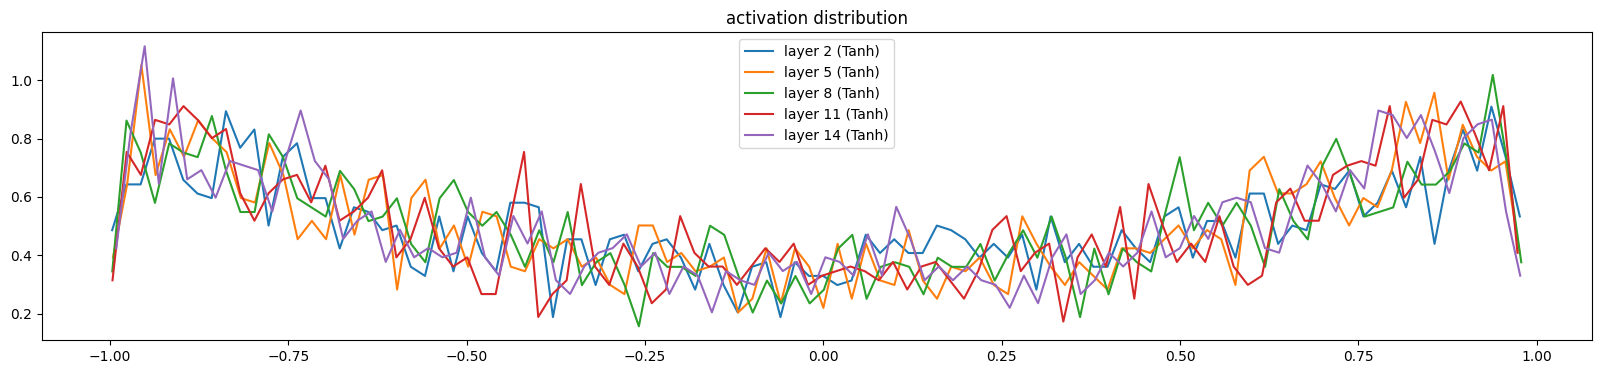

In [116]:
plt.figure(figsize=(20,4))
legends = []
for i , layer in enumerate(layers[:-1]):
    if isinstance(layer, Tanh):
        t = layer.out
        print(f'layer {i} (layer.__class__.__name__) : mean {t.mean()}, std {t.std()}, saturated {(t.abs() > 0.97).float().mean()*100}%)')
        hy, hx = torch.histogram(t, density=True)
        plt.plot(hx[:-1].detach(), hy.detach())
        legends.append(f'layer {i} ({layer.__class__.__name__})')
plt.legend(legends)
plt.title('activation distribution')

layer 2 (layer.__class__.__name__) : mean -5.238689690378884e-12, std 0.00344372377730906, saturated 0.0%)
layer 5 (layer.__class__.__name__) : mean 8.73114894186372e-13, std 0.0031327572651207447, saturated 0.0%)
layer 8 (layer.__class__.__name__) : mean 1.0477379380757768e-11, std 0.0029847980476915836, saturated 0.0%)
layer 11 (layer.__class__.__name__) : mean 5.8207661780829145e-12, std 0.0027214447036385536, saturated 0.0%)
layer 14 (layer.__class__.__name__) : mean -1.1641532356165829e-11, std 0.002643635030835867, saturated 0.0%)


Text(0.5, 1.0, 'gradient distribution')

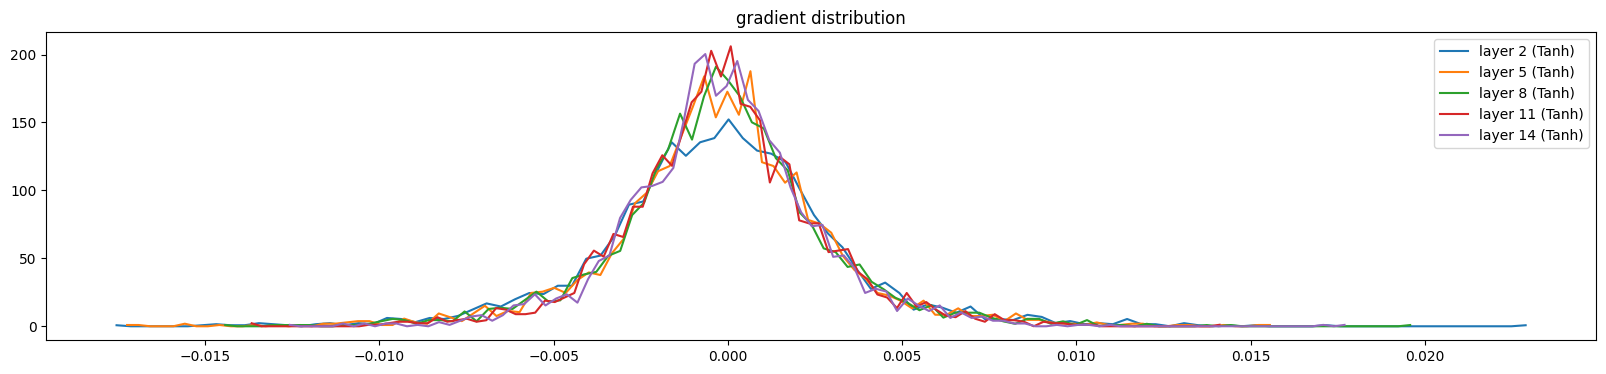

In [117]:
plt.figure(figsize=(20,4))
legends = []
for i , layer in enumerate(layers[:-1]):
    if isinstance(layer, Tanh):
        t = layer.out.grad
        print(f'layer {i} (layer.__class__.__name__) : mean {t.mean()}, std {t.std()}, saturated {(t.abs() > 0.97).float().mean()*100}%)')
        hy, hx = torch.histogram(t, density=True)
        plt.plot(hx[:-1].detach(), hy.detach())
        legends.append(f'layer {i} ({layer.__class__.__name__})')
plt.legend(legends)
plt.title('gradient distribution')

Weight (torch.Size([27, 10])) : mean -5.51894849265544e-11, std 0.009015916846692562, grad:data ratio 0.009006822481751442
Weight (torch.Size([30, 100])) : mean -7.261594146257266e-05, std 0.008409940637648106, grad:data ratio 0.02690955623984337
Weight (torch.Size([100, 100])) : mean 0.0001005262165563181, std 0.0075088804587721825, grad:data ratio 0.044927820563316345
Weight (torch.Size([100, 100])) : mean 3.3667201932985336e-05, std 0.007146462798118591, grad:data ratio 0.042384274303913116
Weight (torch.Size([100, 100])) : mean 4.492657899390906e-05, std 0.006582124158740044, grad:data ratio 0.03922094777226448
Weight (torch.Size([100, 100])) : mean -4.36942937085405e-05, std 0.00584370968863368, grad:data ratio 0.0348079614341259
Weight (torch.Size([100, 27])) : mean 6.389896589098498e-05, std 0.01161015871912241, grad:data ratio 0.0696687325835228


Text(0.5, 1.0, 'weights gradient distribution')

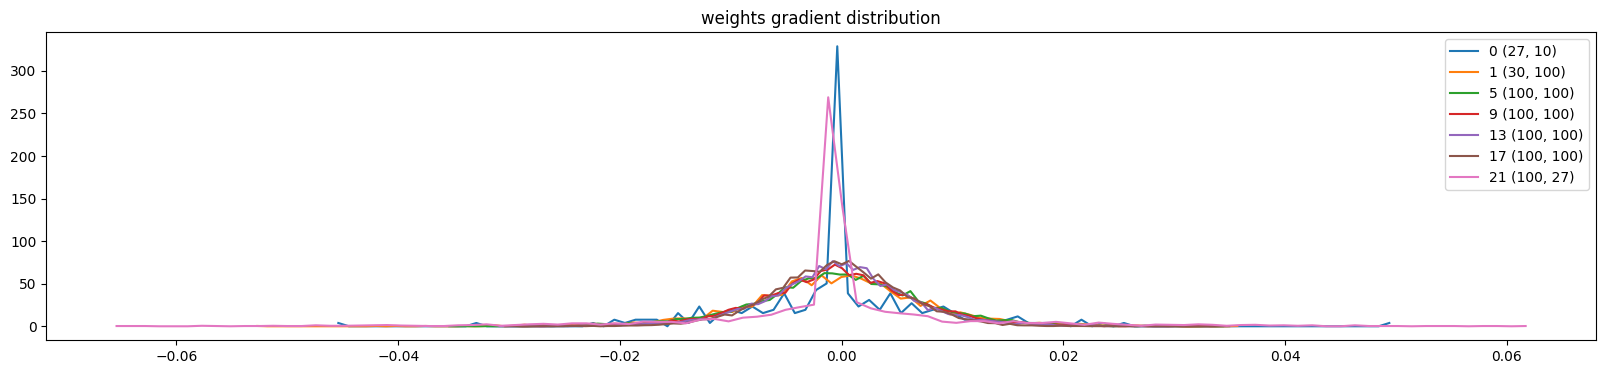

In [118]:
plt.figure(figsize=(20,4))
legends = []
for i , p in enumerate(parameters):
    t = p.grad
    if p.ndim == 2:
        print(f'Weight ({p.shape}) : mean {t.mean()}, std {t.std()}, grad:data ratio {t.std()/ p.std()}')
        hy, hx = torch.histogram(t, density=True)
        plt.plot(hx[:-1].detach(), hy.detach())
        legends.append(f'{i} {tuple(p.shape)}')
plt.legend(legends)
plt.title('weights gradient distribution')

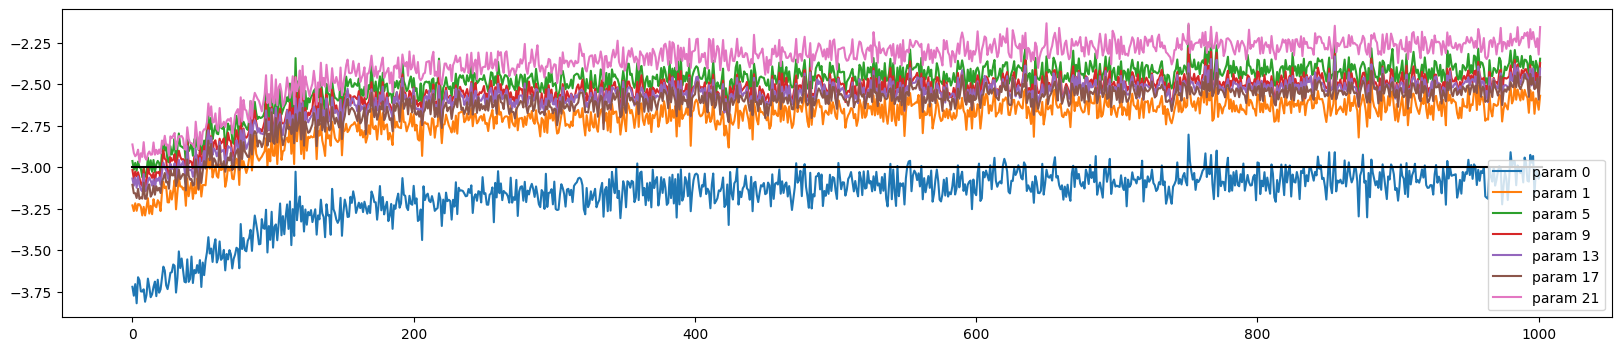

In [119]:
plt.figure(figsize=(20,4))
legends = []
for i,p in enumerate(parameters):
    if p.ndim == 2:
        plt.plot([ud[j][i] for j in range(len(ud))])
        legends.append(f'param {i}')
plt.plot([0, len(ud)], [-3,-3], 'k')
plt.legend(legends)